# GNN with PyTorch Geometric — Molecular Solubility

An end-to-end graph neural network baseline: data loading, batching, training loop,
evaluation, and comparison against the XGBoost scaffold-split RMSE of **0.940**.

`torch_geometric.utils.from_smiles` supplies pre-featurized atoms and bonds — 9 integer
features per atom (atomic number, chirality, degree, formal charge, hybridization,
aromaticity, ring membership, hydrogen count, radical) and 3 per bond (type, stereo,
ring membership). Training runs on CPU; 1,128 molecules take seconds per epoch.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_smiles
from torch_geometric.nn import GCNConv, GATConv, GINConv, global_mean_pool, global_add_pool, global_max_pool

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch          {torch.__version__}")
print(f"torch_geometric {torch_geometric.__version__}")
print(f"Device         {DEVICE}")

torch          2.13.0+cu130
torch_geometric 2.8.0.post1
Device         cpu


## 1. Load data and compute scaffolds

In [2]:
df = pd.read_csv("delaney-processed.csv")
Target = 'measured log solubility in mols per litre'

def get_scaffold(smi):
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(smiles=smi, includeChirality=False)
    except Exception:
        return ""

df["scaffold"] = df["smiles"].apply(get_scaffold)
print(f"Rows: {len(df)}  |  Unique scaffolds: {df['scaffold'].nunique()}")

Rows: 1128  |  Unique scaffolds: 269


## 2. SMILES → PyG graph objects

`from_smiles` returns a `Data` object per molecule:
- `data.x`: `LongTensor` of shape `(num_atoms, 9)` — categorical atom features
- `data.edge_index`: `LongTensor` of shape `(2, num_edges)` — bond connectivity (directed, so each undirected bond appears twice)
- `data.edge_attr`: `LongTensor` of shape `(num_edges, 3)` — categorical bond features

We attach `data.y` (the target) and cast `x`/`edge_attr` to float so they can be fed
to standard GNN layers. **A more elegant approach is per-feature embedding lookups**
— we'll flag that as a possible extension.

In [3]:
def smiles_to_data(smi, y_val):
    data = from_smiles(smi)
    if data is None or data.num_nodes == 0:
        return None
    # Cast categorical integer features to float for GCN/GAT compatibility.
    data.x = data.x.float()
    data.edge_attr = data.edge_attr.float()
    data.y = torch.tensor([y_val], dtype=torch.float)
    return data

data_list = []
skipped = 0
for smi, y_val in zip(df["smiles"], df[Target]):
    d = smiles_to_data(smi.strip(), y_val)
    if d is None:
        skipped += 1
    else:
        data_list.append(d)

# Feature dimensions we'll need to reference in the model class
NODE_FEAT_DIM = data_list[0].x.shape[1]
EDGE_FEAT_DIM = data_list[0].edge_attr.shape[1]

print(f"Built {len(data_list)} PyG graphs, skipped {skipped}")
print(f"Node feature dim: {NODE_FEAT_DIM}   Edge feature dim: {EDGE_FEAT_DIM}")

# Sanity-print one graph
sample = data_list[0]
print(f"\nExample graph (index 0):")
print(f"  {sample.num_nodes} atoms, {sample.num_edges} directed edges")
print(f"  x.shape={tuple(sample.x.shape)}, edge_attr.shape={tuple(sample.edge_attr.shape)}, y={sample.y.item():.3f}")

Built 1128 PyG graphs, skipped 0
Node feature dim: 9   Edge feature dim: 3

Example graph (index 0):
  32 atoms, 68 directed edges
  x.shape=(32, 9), edge_attr.shape=(68, 3), y=-0.770


## 3. Scaffold split (same as `Scaffold_split.ipynb`)

We reuse the exact same splitter for a like-for-like comparison against XGBoost.

In [4]:
def scaffold_split_indices(df, test_frac=0.20):
    groups = df.groupby("scaffold").indices
    groups_sorted = sorted(groups.values(), key=len, reverse=True)
    n_train_target = int(round(len(df) * (1 - test_frac)))
    train_idx, test_idx = [], []
    for g in groups_sorted:
        if len(train_idx) + len(g) <= n_train_target:
            train_idx.extend(g)
        else:
            test_idx.extend(g)
    return np.array(train_idx), np.array(test_idx)

train_idx, test_idx = scaffold_split_indices(df, test_frac=0.20)
train_set = [data_list[i] for i in train_idx]
test_set  = [data_list[i] for i in test_idx]

train_scaffolds = set(df.iloc[train_idx]["scaffold"])
test_scaffolds  = set(df.iloc[test_idx]["scaffold"])
print(f"Train: {len(train_set)}   Test: {len(test_set)}   Scaffold overlap: {len(train_scaffolds & test_scaffolds)}")

Train: 902   Test: 226   Scaffold overlap: 0


## 4. DataLoaders — batching graphs

**Batching graphs is non-trivial**: you can't just stack graphs into a tensor because
they have different numbers of nodes. PyG's `DataLoader` handles this by
concatenating all graphs in a batch into one large "super-graph" with disconnected
components, and providing a `batch` vector `(total_nodes,)` mapping every node
back to its original graph index. This is essential for the pooling step in your
model — `global_mean_pool(x, batch)` aggregates atom embeddings back to
per-molecule embeddings using that `batch` vector.

In [5]:
BATCH_SIZE = 32

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

# Inspect one batch
sample_batch = next(iter(train_loader))
print(f"One batch contains {sample_batch.num_graphs} graphs")
print(f"  x.shape         = {tuple(sample_batch.x.shape)}   (all atoms in the batch concatenated)")
print(f"  edge_index.shape= {tuple(sample_batch.edge_index.shape)}")
print(f"  edge_attr.shape = {tuple(sample_batch.edge_attr.shape)}")
print(f"  batch.shape     = {tuple(sample_batch.batch.shape)}   (assigns each atom to a graph)")
print(f"  y.shape         = {tuple(sample_batch.y.shape)}   (one target per graph)")

One batch contains 32 graphs
  x.shape         = (372, 9)   (all atoms in the batch concatenated)
  edge_index.shape= (2, 750)
  edge_attr.shape = (750, 3)
  batch.shape     = (372,)   (assigns each atom to a graph)
  y.shape         = (32,)   (one target per graph)


## 5. The model

A baseline 2-layer GCN:

```text
GCNConv(node_feat_dim -> hidden) -> ReLU
GCNConv(hidden -> hidden)        -> ReLU
global_mean_pool over atoms in each graph
Linear(hidden -> hidden)         -> ReLU
Linear(hidden -> 1)
```

`forward` takes `(x, edge_index, edge_attr, batch)` and returns one scalar per graph.
The `batch` vector maps every atom back to its molecule, which is what lets
`global_mean_pool` aggregate atom embeddings into per-molecule embeddings.

In [6]:
# BASELINE GCN — Standard 2-layer graph convolutional network + MLP head.
#
# Architecture (in order):
#   GCNConv(node_feat_dim -> hidden) -> ReLU
#   GCNConv(hidden -> hidden)        -> ReLU
#   global_mean_pool over atoms in each graph
#   Linear(hidden -> hidden)         -> ReLU
#   Linear(hidden -> 1)
#   squeeze(-1)  # (batch,) instead of (batch, 1)
class MyGNN(nn.Module):
    def __init__(self, node_feat_dim: int, hidden_dim: int):
        super().__init__()
        self.conv1 = GCNConv(node_feat_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        # Two message-passing layers with ReLU between them.
        # After each GCNConv, each atom embedding aggregates info from 1 more hop.
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        # Pool atom embeddings into a per-graph embedding using the batch vector
        h = global_mean_pool(x, batch)
        # MLP head to a scalar per molecule
        out = self.head(h)
        return out.squeeze(-1)


## 6. Training and evaluation utilities

Standard PyTorch training loop pattern. The `evaluate` function puts the model
in eval mode and disables gradient tracking (essential — otherwise you leak
memory and slow down evaluation).

In [7]:
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, n_graphs = 0.0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = loss_fn(pred, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        n_graphs += batch.num_graphs
    return total_loss / n_graphs

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_pred, all_true = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        all_pred.append(pred.cpu().numpy())
        all_true.append(batch.y.cpu().numpy())
    y_pred = np.concatenate(all_pred)
    y_true = np.concatenate(all_true)
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE":  mean_absolute_error(y_true, y_pred),
        "R2":   r2_score(y_true, y_pred),
        "y_pred": y_pred,
        "y_true": y_true,
    }

## 7. Train

Instantiate `MyGNN`, pick an optimizer (`Adam` with `lr=1e-3` is a safe default),
and train for a few dozen epochs. The plumbing here is complete — this will run
once you've filled in the model class.

**Suggested starting hyperparameters:**
- `hidden_dim = 64`
- `lr = 1e-3`
- `n_epochs = 100`
- Loss: MSE (via `nn.MSELoss()`)
- Optimizer: `torch.optim.Adam`

Track training loss + test RMSE each epoch to plot a learning curve.

In [8]:
HIDDEN_DIM = 64
LR = 1e-3
N_EPOCHS = 100
WEIGHT_DECAY = 1e-5   # small L2 regularization

model = MyGNN(node_feat_dim=NODE_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.MSELoss()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

history = {"epoch": [], "train_loss": [], "test_rmse": []}

for epoch in tqdm(range(1, N_EPOCHS + 1), desc="Training"):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    if epoch % 5 == 0 or epoch == 1:
        eval_res = evaluate(model, test_loader)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["test_rmse"].append(eval_res["RMSE"])

# Final eval
final = evaluate(model, test_loader)
print(f"\nFinal test  RMSE = {final['RMSE']:.4f}")
print(f"Final test  MAE  = {final['MAE']:.4f}")
print(f"Final test  R2   = {final['R2']:.4f}")

Trainable parameters: 9,025


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   1%|          | 1/100 [00:00<01:11,  1.38it/s]

Training:   2%|▏         | 2/100 [00:00<00:40,  2.41it/s]

Training:   3%|▎         | 3/100 [00:01<00:34,  2.80it/s]

...

Training:  98%|█████████▊| 98/100 [00:24<00:00,  3.66it/s]

Training:  99%|█████████▉| 99/100 [00:24<00:00,  4.06it/s]

Training: 100%|██████████| 100/100 [00:24<00:00,  3.96it/s]

Training: 100%|██████████| 100/100 [00:24<00:00,  4.05it/s]


Final test  RMSE = 1.2196
Final test  MAE  = 0.9524
Final test  R2   = 0.6518


## 8. Training curve

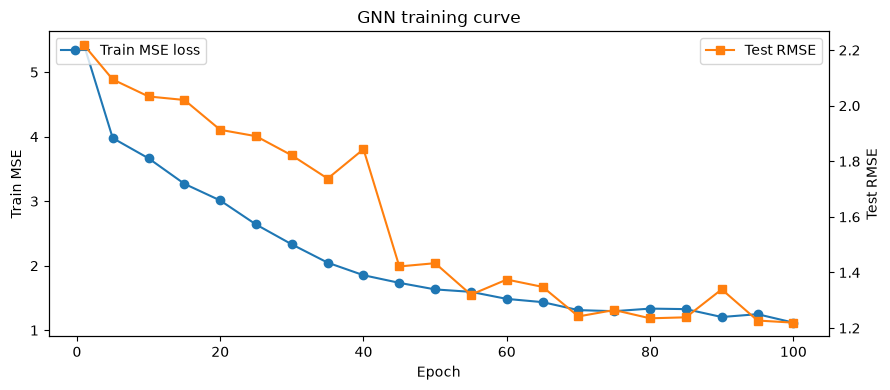

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history["epoch"], history["train_loss"], label="Train MSE loss", marker="o")
ax2 = ax.twinx()
ax2.plot(history["epoch"], history["test_rmse"], color="tab:orange", label="Test RMSE", marker="s")
ax.set_xlabel("Epoch")
ax.set_ylabel("Train MSE")
ax2.set_ylabel("Test RMSE")
ax.set_title("GNN training curve")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig("figures/gnn_training_curve.pdf", bbox_inches="tight")
plt.show()

## 9. Predicted-vs-actual + residuals diagnostic

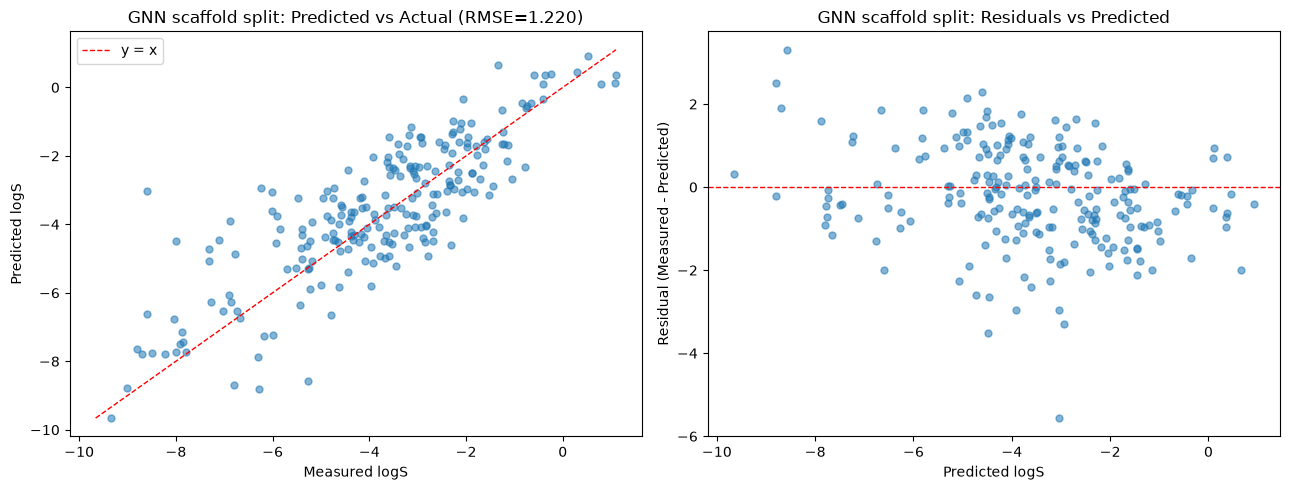

In [10]:
y_true = final["y_true"]
y_pred = final["y_pred"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_true, y_pred, alpha=0.55, s=25)
lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
axes[0].set_xlabel("Measured logS")
axes[0].set_ylabel("Predicted logS")
axes[0].set_title(f"GNN scaffold split: Predicted vs Actual (RMSE={final['RMSE']:.3f})")
axes[0].legend()

resid = y_true - y_pred
axes[1].scatter(y_pred, resid, alpha=0.55, s=25)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted logS")
axes[1].set_ylabel("Residual (Measured - Predicted)")
axes[1].set_title("GNN scaffold split: Residuals vs Predicted")
plt.tight_layout()
plt.savefig("figures/gnn_diagnostic_scaffold.pdf", bbox_inches="tight")
plt.show()

## 10. Comparison with XGBoost under scaffold split

In [11]:
compare = pd.DataFrame({
    "Model":               ["XGBoost (7 hand-crafted feats)", "GNN (learned atom/bond feats)"],
    "Test RMSE":           [0.940, final["RMSE"]],
    "Test R2":             [0.793, final["R2"]],
})
print(compare.round(4).to_string(index=False))

                         Model  Test RMSE  Test R2
XGBoost (7 hand-crafted feats)     0.9400   0.7930
 GNN (learned atom/bond feats)     1.2196   0.6518
